# Plot QC improvement with added FC

In [3]:
library(tidyverse)
library(ggplot2)

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [4]:
qc_asm <- read_tsv("../../assembly/qc/qc_flowcells.tsv", col_type = 'cdcccc') 
head(qc_asm)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
Number of mapped sequences,19122,NA,unphased_verkko,TUE_02_01UL,stat,NA
Number of primary alignments,45269,NA,unphased_verkko,TUE_02_01UL,stat,NA
Number of secondary alignments,34659,NA,unphased_verkko,TUE_02_01UL,stat,NA
Number of primary alignments with >65535 CIGAR operations,0,NA,unphased_verkko,TUE_02_01UL,stat,NA
Number of bases in mapped sequences,6685275250,NA,unphased_verkko,TUE_02_01UL,stat,NA
Number of mapped bases,6642871159,NA,unphased_verkko,TUE_02_01UL,stat,NA


In [5]:
n_UL = c(1,2,3,4,5,6)
n_DX = c(0,1,2)
samples = c("TUE_02")

In [6]:
combinations <- as_tibble(expand.grid("n_UL" = n_UL, "n_DX" = as.factor(n_DX), "sample" = samples)) %>%
    mutate(asm_name = ifelse(n_DX == 0,
        paste0(sample,  "_", str_pad(n_UL, 2, pad = 0), "UL"),
        paste0(sample,  "_", str_pad(n_UL, 2, pad = 0), "UL", "_", str_pad(n_DX, 2, pad = "0"), "DX")))

In [ ]:
dt <- inner_join(
  combinations,
  qc_asm,
  by = join_by("asm_name"),
)

head(dt)

n_UL,n_DX,sample,asm_name,metric,value,haplotype,asm_method,source,chromosome
<dbl>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0,TUE_02,TUE_02_01UL,Number of mapped sequences,19122,NA,unphased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of primary alignments,45269,NA,unphased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of secondary alignments,34659,NA,unphased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of primary alignments with >65535 CIGAR operations,0,NA,unphased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of bases in mapped sequences,6685275250,NA,unphased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,Number of mapped bases,6642871159,NA,unphased_verkko,stat,NA


In [12]:
print(paste("Rows unprocessed:", nrow(dt)))
source("../scripts/13_process_assembly_qc.R")

dt_processed <- process_qc_table(dt) %>% mutate(haplotype = ifelse(is.na(haplotype), "both", haplotype))
print(paste("Rows processed:", nrow(dt_processed)))


[1] "Rows unprocessed: 20844"
[1] "Rows processed: 1188"


In [16]:
metrics <- dt_processed %>% select('metric') %>% unique() %>% pull()
for (i in 1:length(metrics))
{
    print(paste("Plotting", metrics[i]))
    p <- ggplot(dt_processed %>% filter(metric == metrics[i]), aes(x = n_UL, y = value, col = n_DX)) +
        #geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        geom_line(aes(linetype = haplotype)) +
        # Okabe-Ito palette (colorblind friendly)
        scale_fill_manual(values = c( "#E69F00", "#56B4E9", "#009E73","#999999", "#F0E442")) +
        facet_wrap(~asm_method) +
        theme_classic() +
        labs(
            x = "n UL Flowcells",
            y = metrics[i],
            fill = "n DX Flowcells"
         )
    ggsave(paste0("../../doc/img/flowcells/", metrics[i], ".png"), p)
}

[1] "Plotting Assembly Length"


Saving 7 x 7 in image


[1] "Plotting % of Ref covered by Assembly"


Saving 7 x 7 in image


[1] "Plotting % of Ref duplicated in Assembly"


...

Saving 7 x 7 in image


[1] "Plotting Overall Switch Rate (%)"


Saving 7 x 7 in image


[1] "Plotting Overall Switch Flip Rate (%)"


Saving 7 x 7 in image


In [13]:
# export dt to tsv file
write_tsv(dt_processed, "../../doc/tables/flowcells_qc.tsv")

## Input data comparison


### Compare HQ reads

In [17]:
source("../scripts/02_plot_read_stats.R")

asm_names <- dt %>% select(asm_name, n_DX, n_UL) %>% unique()

l_dt_qc <- list()
for (i in 1:nrow(asm_names)) {
    print(paste("Processing", asm_names$asm_name[i]))
    asm_prefix <- if(str_count(asm_names$asm_name[i], "_") >= 3) {
      sub("_[^_]*$", "", asm_names$asm_name[i])
    } else {
      asm_names$asm_name[i]
    }
    if (asm_names$n_DX[i] == 0) {
        if (asm_names$n_UL[i] < 3) {
            read_type <- "HQ_herro"
        } else {
            read_type <- "HQ_herro.50x"
        }
    } else if (asm_names$n_DX[i] == 1) {
        if (asm_names$n_UL[i] < 3) {
            read_type <- "HQ_combined.10x_maxx"
        } else if (asm_names$n_UL[i] == 3) {
            read_type <- "HQ_combined.10x_30x"
        } else if (asm_names$n_UL[i] == 4) {
            read_type <- "HQ_combined.10x_40x"
        } else if (asm_names$n_UL[i] == 5) {
            read_type <- "HQ_combined.10x_30x"
        } else if (asm_names$n_UL[i] == 6) {
            read_type <- "HQ_combined.10x_40x"
        } 
    } else if (asm_names$n_DX[i] == 2) {
        read_type <- "HQ_combined.maxx_maxx"
    } else {
        print("Error: n_DX is not 0, 1, or 2")
    }
    file_path <- paste0("../../assembly/input_qc/", asm_prefix,"/", asm_prefix, ".", read_type, "/read_stats.txt")
    l_dt_qc[[asm_names$asm_name[i]]] <- process_sequencing_file(file_path)
}


[1] "Processing TUE_02_01UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_01UL/TUE_02_01UL.HQ_herro/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in calculate_2d_density(result$plot_data):
“Skipping 2D density for sample TUE_02_01UL_HQ_herro due to insufficient variation”


[1] "Processing TUE_02_02UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_02UL/TUE_02_02UL.HQ_herro/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in calculate_2d_density(result$plot_data):
“Skipping 2D density for sample TUE_02_02UL_HQ_herro due to insufficient variation”


[1] "Processing TUE_02_03UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_03UL/TUE_02_03UL.HQ_herro.50x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


...

Warning message in value[[3L]](cond):
“Zero scale estimate for y values in sample TUE_02_04UL_HQ_combined.maxx_maxx”
Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Processing TUE_02_05UL_02DX"
[1] "Reading file: ../../assembly/input_qc/TUE_02_05UL/TUE_02_05UL.HQ_combined.maxx_maxx/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in value[[3L]](cond):
“Zero scale estimate for y values in sample TUE_02_05UL_HQ_combined.maxx_maxx”
Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Processing TUE_02_06UL_02DX"
[1] "Reading file: ../../assembly/input_qc/TUE_02_06UL/TUE_02_06UL.HQ_combined.maxx_maxx/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in value[[3L]](cond):
“Zero scale estimate for y values in sample TUE_02_06UL_HQ_combined.maxx_maxx”
Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


In [187]:
for (i in 1:length(l_dt_qc)) {
    l_dt_qc[[i]]$summary_stats$sample_name <- names(l_dt_qc)[i]
    l_dt_qc[[i]]$read_length_density$sample_name <- names(l_dt_qc)[i]
    l_dt_qc[[i]]$quality_density$sample_name <- names(l_dt_qc)[i]
    l_dt_qc[[i]]$density_2d$sample_name <- names(l_dt_qc)[i]
}

In [188]:
# Combine all summary statistics into a single data frame
dt_stats_hq <- bind_rows(lapply(l_dt_qc, function(x) x$summary_stats)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_read_length_density_hq <- bind_rows(lapply(l_dt_qc, function(x) x$read_length_density)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_quality_density_hq <- bind_rows(lapply(l_dt_qc, function(x) x$quality_density)) %>%  
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_density_2d_hq <- bind_rows(lapply(l_dt_qc, function(x) x$density_2d)) %>%  
    inner_join(asm_names, by = c("sample_name" = "asm_name"))

In [191]:
dt_stats_hq

sample_name,N50,mean_quality,median_quality,total_bases,num_reads,mean_read_length,median_read_length,n_DX,n_UL
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<fct>,<dbl>
TUE_02_01UL,30919,33.00000,33.00000,99467912039,4763903,20879.50,14045,0,1
TUE_02_02UL,44696,33.00000,33.00000,206846184224,7619312,27147.62,16377,0,2
TUE_02_03UL,80466,33.00000,33.00000,160000022814,2066094,77440.82,64294,0,3
TUE_02_04UL,100052,33.00000,33.00000,160000056144,1596243,100235.40,87421,0,4
TUE_02_05UL,121365,33.00000,33.00000,160000071170,1302576,122833.58,109308,0,5
TUE_02_06UL,129349,33.00000,33.00000,160000060905,1212115,132000.73,118821,0,6
TUE_02_01UL_01DX,27012,32.42828,32.42828,116378538830,5700619,20415.07,14999,1,1
TUE_02_02UL_01DX,40433,32.61908,32.61908,223756811015,8556028,26151.95,16465,1,2
TUE_02_03UL_01DX,100062,31.19855,31.19855,112910635089,1809197,62409.25,30572,1,3


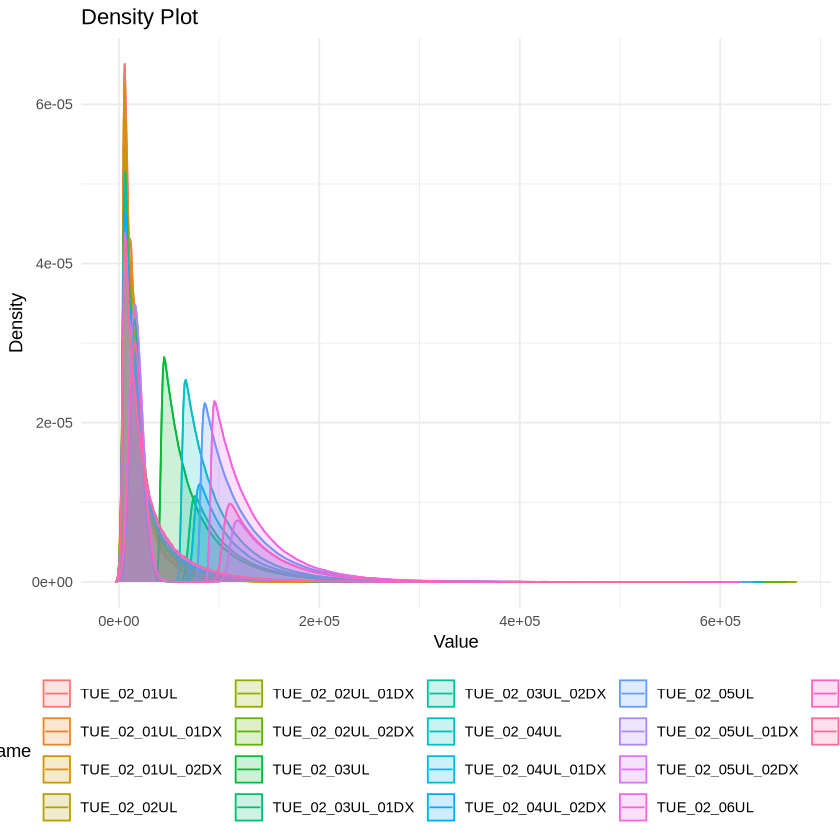

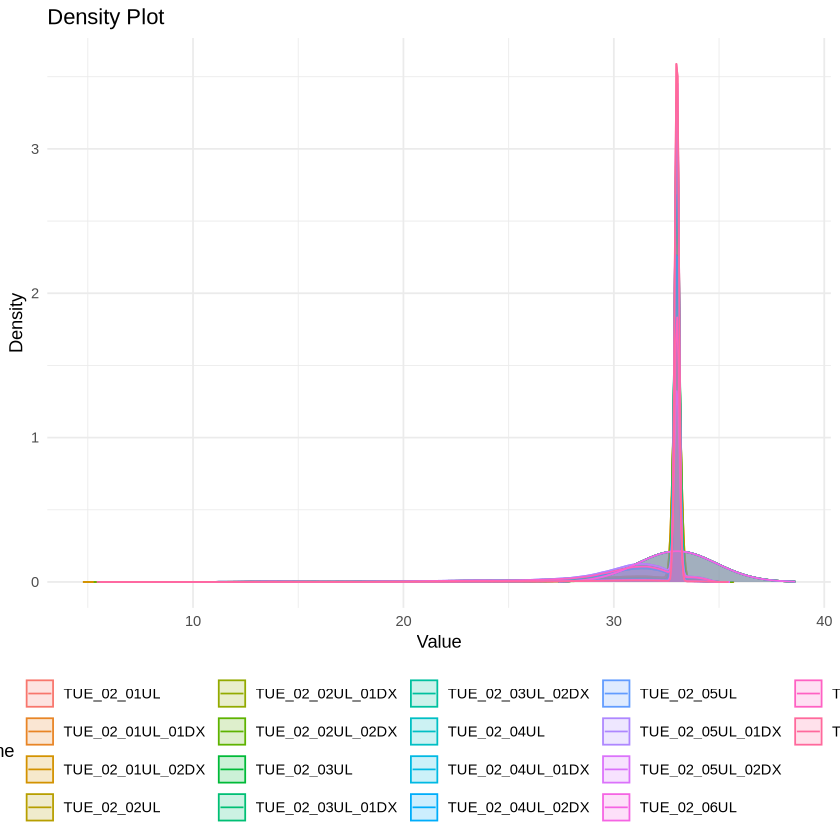

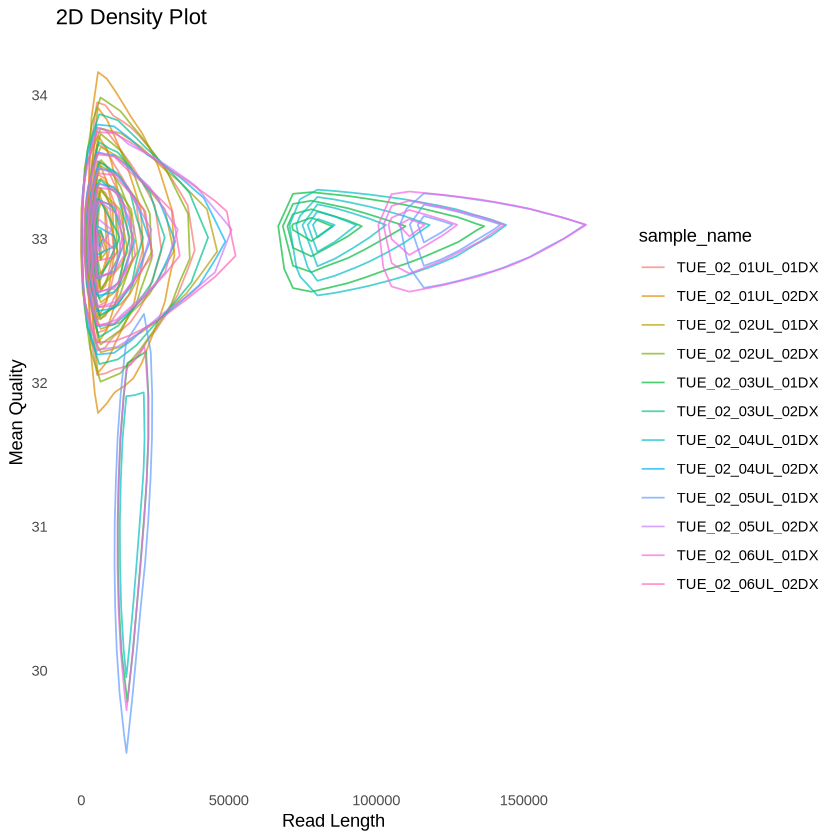

In [201]:
plot_1d_density(dt_read_length_density_hq)
plot_1d_density(dt_quality_density_hq)
plot_2d_density(dt_density_2d_hq)

Interpretation of these results:
- Quality of Herro reads, based on QC scores cannot be estimated
- Using more then 4 Flowcells leads to higher input read lengths due to read subsampling.

### Compare UL reads

In [196]:
l_ul_qc <- list()
asm_names_ul <- asm_names %>% filter(n_DX == 0)
for (i in 1:nrow(asm_names_ul)) {
    print(paste("Processing", asm_names_ul$asm_name[i]))
    asm_prefix <- if(str_count(asm_names$asm_name[i], "_") >= 3) {
      sub("_[^_]*$", "", asm_names$asm_name[i])
    } else {
      asm_names$asm_name[i]
    }
    if (asm_names$n_UL[i] < 5) {
      read_type <- "UL"
    } else {
      read_type <- "UL.70x"
    }
    file_path <- paste0("../../assembly/input_qc/", asm_prefix,"/", asm_prefix, ".", read_type, "/read_stats.txt")
    l_ul_qc[[asm_names$asm_name[i]]] <- process_sequencing_file(file_path)
}

[1] "Processing TUE_02_01UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_01UL/TUE_02_01UL.UL/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Processing TUE_02_02UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_02UL/TUE_02_02UL.UL/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Processing TUE_02_03UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_03UL/TUE_02_03UL.UL/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


...

Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Processing TUE_02_05UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_05UL/TUE_02_05UL.UL.70x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Processing TUE_02_06UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_06UL/TUE_02_06UL.UL.70x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


In [197]:
for (i in 1:length(l_ul_qc)) {
    l_ul_qc[[i]]$summary_stats$sample_name <- names(l_ul_qc)[i]
    l_ul_qc[[i]]$read_length_density$sample_name <- names(l_ul_qc)[i]
    l_ul_qc[[i]]$quality_density$sample_name <- names(l_ul_qc)[i]
    l_ul_qc[[i]]$density_2d$sample_name <- names(l_ul_qc)[i]
}


In [198]:
# Combine all summary statistics into a single data frame
dt_stats_ul <- bind_rows(lapply(l_ul_qc, function(x) x$summary_stats)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_read_length_density_ul <- bind_rows(lapply(l_ul_qc, function(x) x$read_length_density)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_quality_density_ul <- bind_rows(lapply(l_ul_qc, function(x) x$quality_density)) %>%  
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_density_2d_ul <- bind_rows(lapply(l_ul_qc, function(x) x$density_2d)) %>%  
    inner_join(asm_names, by = c("sample_name" = "asm_name"))

In [199]:
dt_stats_ul

sample_name,N50,mean_quality,median_quality,total_bases,num_reads,mean_read_length,median_read_length,n_DX,n_UL
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<fct>,<dbl>
TUE_02_01UL,28950,24.07778,24.07778,112447587626,8345004,13474.84,6449,0,1
TUE_02_02UL,43225,23.99214,23.99214,226362384364,12553863,18031.29,7438,0,2
TUE_02_03UL,44412,24.26153,24.26153,325159423571,17601541,18473.35,7616,0,3
TUE_02_04UL,46957,24.49163,24.49163,457880046194,23032277,19879.93,8416,0,4
TUE_02_05UL,104366,27.01033,27.01033,224000051468,2198474,101888.88,87739,0,5
TUE_02_06UL,111049,27.27358,27.27358,224000046302,2033415,110159.53,96773,0,6


In [ ]:
p <- ggplot(dt_stats_ul, aes(x = n_UL, y = mean_read_length)) +

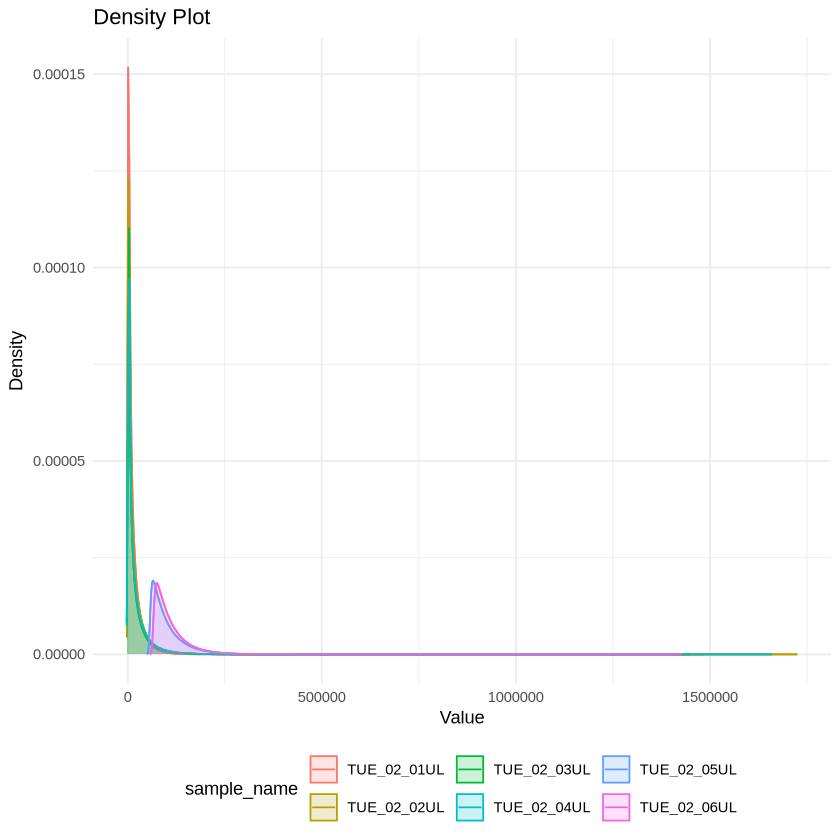

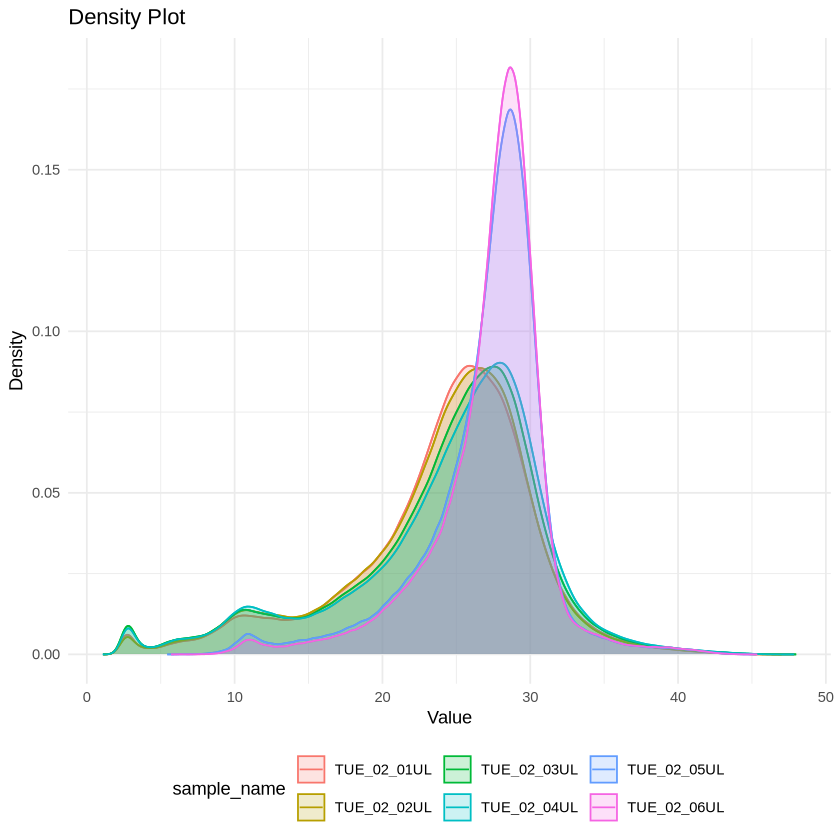

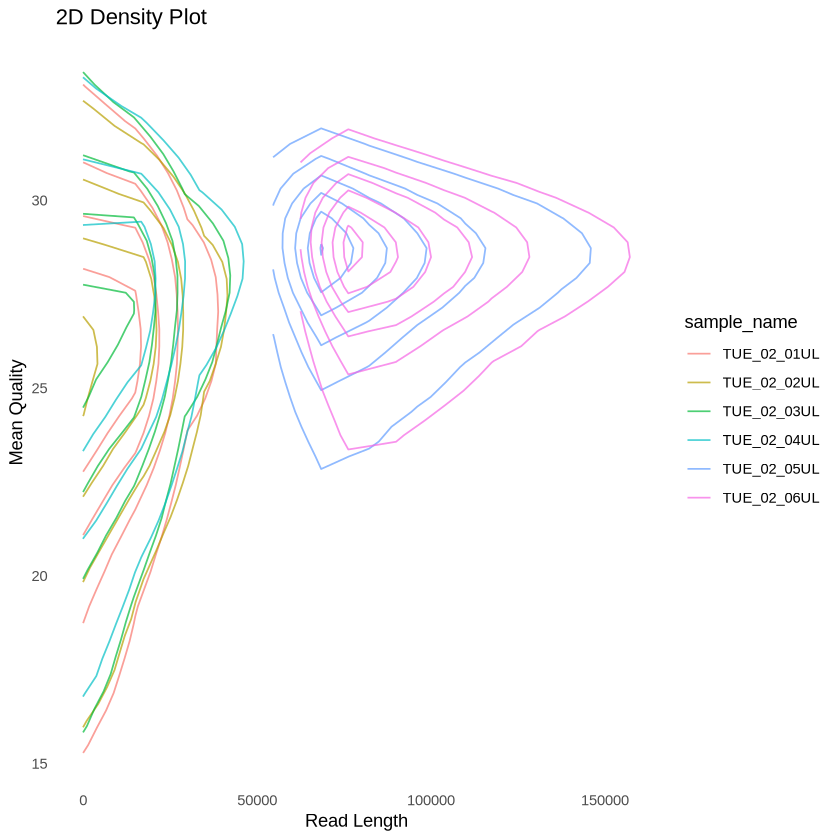

In [200]:
plot_1d_density(dt_read_length_density_ul)
plot_1d_density(dt_quality_density_ul)
plot_2d_density(dt_density_2d_ul)

During dataset setup, UL n=1 to n=5 where not filtered. Maybe this could be redone.

## Export QC data as table

In [205]:
dt_processed


n_UL,n_DX,sample,asm_name,metric,value,haplotype,asm_method,source,chromosome
<dbl>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0,TUE_02,TUE_02_01UL,Assembly Length,2.907174e+09,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,% of Ref covered by Assembly,8.873000e-01,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,% of Ref duplicated in Assembly,1.360000e-02,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,% of Assembly covered by Ref,9.651000e-01,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,NG75,5.833740e+07,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,NG50,1.352128e+08,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,NGA50,3.011018e+06,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,Average Ungapped Alignment length,4.012744e+06,haplotype1,phased_verkko,asmstat,NA
1,0,TUE_02,TUE_02_01UL,Number of Breaks in Assembly,1.176100e+04,haplotype1,phased_verkko,asmstat,NA


In [222]:
dt_qc_table <- dt_processed %>%
  filter() %>%
  mutate(haplotype = ifelse(haplotype == "assembly", "both", haplotype)) %>%
  group_by(asm_name, metric, haplotype) %>%
  summarise(value = sum(value, na.rm = TRUE), .groups = 'drop') %>%
  mutate(
    formatted_value = case_when(

      metric %in% c("Error Rate") ~ paste0(round(value * 100, 3), "%"),
      TRUE ~ as.character(round(value, 2))
    )
  ) %>%
  select(-value) %>%  # Remove original value column
  pivot_wider(
    names_from = metric, 
    values_from = formatted_value
  )

write_tsv(dt_qc_table, "../../doc/tables/qc_flowcell_table.tsv")

dt_qc_table  %>%
  knitr::kable()



|asm_name         |haplotype  |% of Assembly covered by Ref |% of Ref covered by Assembly |% of Ref duplicated in Assembly |Assembly Length |Average Ungapped Alignment length |Covered Variants |Error Rate |Genome Completeness |Missing Multi-Copy Genes (%) |NG50      |NG75      |NGA50   |Number of Breaks in Assembly |Number of T2T chromosomes |Number of Y Chromosomes |Phase Blocks |Quality Value |Switch Flip Rate (%) |Switch Rate (%) |Variants |Variants Phased |Variants Unphased |singletons |
|:----------------|:----------|:----------------------------|:----------------------------|:-------------------------------|:---------------|:---------------------------------|:----------------|:----------|:-------------------|:----------------------------|:---------|:---------|:-------|:----------------------------|:-------------------------|:-----------------------|:------------|:-------------|:--------------------|:---------------|:--------|:---------------|:-----------------|:----------|
|TUE

In [237]:
### Extract metrics for best assembly

dt_qc_table %>%
  filter(asm_name == "TUE_02_03UL") %>%
  pivot_longer(cols = -c(asm_name, haplotype), names_to = "Metric", values_to = "Value") %>%
  na.omit() %>% 
  arrange(Metric, haplotype) %>%
  write_tsv("../../doc/tables/qc_flowcell_table_TUE_02_03UL.tsv")
